![alternative text](../logo.png)

# Hydrology Variables – flood recurrence example

This notebook shows how to retrieve **hydrological climate-projection data** using the `sis-hydrology-variables-derived-projections` dataset, using flood recurrence as an example.

In this example, you will:

1. Build and send a data request using a **bounding box** or a **polygon**
2. Decode the CoverageJSON data into an **xarray Dataset**
3. Visualise the data using the EarthKit plots package (Optional)

---

### What are hydrology variables derived from climate projections?

These variables come from hydrological models driven by bias-adjusted EURO-CORDEX regional climate simulations, on a 5 km grid over the European river network. The dataset includes river discharge, runoff, soil moisture, water temperature, nutrient loads and flood recurrence, across different climate scenarios and time periods. This type of data is used for flood-risk assessment and long-term water management.

More information about **available variables** and **request fields** can be found in:
- README and constraints/sis-hydrology-variables-derived-projections.json
- https://cds.climate.copernicus.eu/datasets/sis-hydrology-variables-derived-projections?tab=overview

## Imports and shared settings

In [1]:
# Uncomment and run this cell if you need to install the dependencies
#!pip install -r requirements.txt

In [2]:
#Data requests and decode
import requests
from covjsonkit.api import Covjsonkit

#Data visualisation
import earthkit.plots as ekp

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="earthkit")

# API endpoint template
base_url = 'https://polytope-dss.ecmwf.int/api/v1/dataset/{dataset}/extract/'

headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json',
}

url = base_url.format(dataset='sis-hydrology-variables-derived-projections')


---

## Example 1 – Bounding-box query

A **bounding box** selects all grid points inside a rectangular region defined by two corner coordinates.

In this request, we retrieve the **50-year flood** — the annual maximum river discharge with a 50-year return period — as a percentage change from the 1971–2000 reference period, at two global warming levels: **+1.5 °C** and **+3.0 °C**.

The bounding box covers the **upper Elbe basin** (roughly 49.5°N–52°N, 12°E–15.5°E). In August 2002 extreme rainfall over this area flooded Prague and Dresden, where the Elbe peaked at a record 9.40 m.

Two fields are specific to this dataset: `period` is a **warming level** (`1_5_c`, `2_0_c`, `3_0_c`) rather than a calendar range, and `variable_type` selects `absolute_values` (m³/s) or, as here, `relative_change_from_reference_period` (%). The driving models are given explicitly in both requests, so the two maps differ only in the scenario.

The API returns data in **CoverageJSON** format.

### 1.1 Send the request

In [3]:
elbe_bbox = [[49.5, 12.0], [52.0, 15.5]]   # [lat_min, lon_min], [lat_max, lon_max]

bbox_request15 = {
    'request': {
        'variable': ['flood_recurrence_50_years_return_period'],
        'experiment': ['degree_scenario'],
        'period': ['1_5_c'],                # warming level: '1_5_c', '2_0_c' or '3_0_c'
        'time_aggregation': 'annual_mean',
        'variable_type': 'relative_change_from_reference_period',
        'gcm': 'ec_earth',
        'rcm': 'rca4',
        'hydrological_model': ['e_hypegrid'],
        'ensemble_member': ['r12i1p1'],
    },
    'feature': {
        'type': 'boundingbox',
        # Coordinates are [lat_min, lon_min] and [lat_max, lon_max]
        'coordinates': elbe_bbox,
    },
}
bbox_request30 = {
    'request': {
        'variable': ['flood_recurrence_50_years_return_period'],
        'experiment': ['degree_scenario'],
        'period': ['3_0_c'],
        'time_aggregation': 'annual_mean',
        'variable_type': 'relative_change_from_reference_period',
        'gcm': 'ec_earth',
        'rcm': 'rca4',
        'hydrological_model': ['e_hypegrid'],
        'ensemble_member': ['r12i1p1'],
    },
    'feature': {
        'type': 'boundingbox',
        'coordinates': elbe_bbox,
    },
}

response_bbox15 = requests.post(url, headers=headers, json=bbox_request15)
response_bbox30 = requests.post(url, headers=headers, json=bbox_request30)

#Print the response status code
print('Status +1.5 C:', response_bbox15.status_code)
print('Status +3.0 C:', response_bbox30.status_code)


Status +1.5 C: 200
Status +3.0 C: 200


### 1.2 Decode the response

The module `covjsonkit` converts the downloaded CoverageJSON dataset into an [xarray Dataset](https://docs.xarray.dev/en/stable/), which gives us a labelled overview of the dataset and makes future post-processing straightforward.

In [4]:
decoder_bbox15 = Covjsonkit().decode(response_bbox15.json()); decoder_bbox30 = Covjsonkit().decode(response_bbox30.json())
ds_bbox15 = decoder_bbox15.to_xarray(); ds_bbox30 = decoder_bbox30.to_xarray()
ds_bbox15

<xarray.Dataset> Size: 110kB
Dimensions:                (datetimes: 1, number: 1, steps: 1, points: 2748)
Coordinates:
  * datetimes              (datetimes) <U19 76B '2019-12-31 18:00:00'
  * number                 (number) int64 8B 0
  * steps                  (steps) int64 8B 0
  * points                 (points) int64 22kB 0 1 2 3 4 ... 2744 2745 2746 2747
    latitude               (points) float64 22kB 49.53 49.53 ... 51.99 51.98
    longitude              (points) float64 22kB 12.02 12.09 ... 15.41 15.49
    levelist               (points) float64 22kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Data variables:
    rdisreturnmax50_tmean  (datetimes, number, steps, points) float64 22kB -3...
Attributes:
    number:   0
    step:     0
    date:     2019-12-31 18:00:00

The variable is named `rdisreturnmax50_tmean` and holds a single field, since a return level is a statistic of the whole 30-year window.

### 1.3 Visualise the data

We plot the two warming levels side by side on a diverging colour scale, with levels symmetric about zero so that the pale middle of the palette sits on "no change": brown means the 50-year flood shrinks, teal means it grows.

We use **Earthkit Plots** package to visualise the data.
Please, find more information and documentation of the package here:
https://earthkit-plots.readthedocs.io

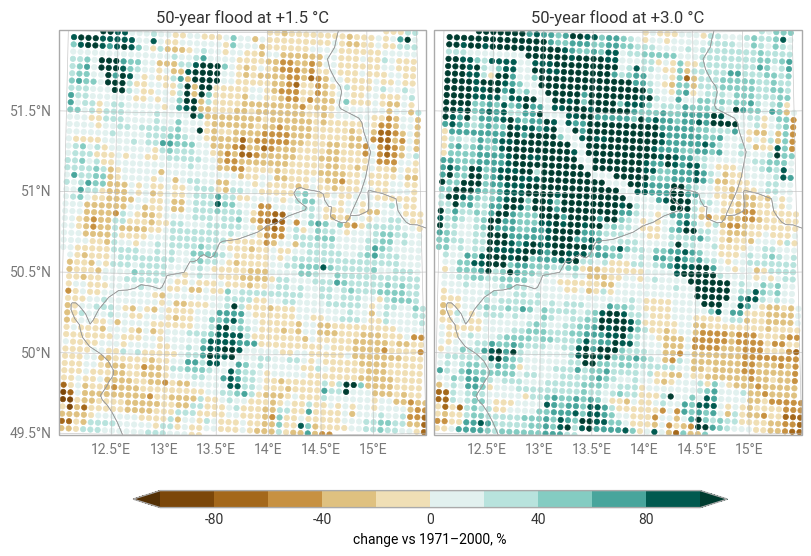

In [5]:
VAR = 'rdisreturnmax50_tmean'

change_levels = list(range(-100, 101, 20))

figure = ekp.Figure(rows=1, columns=2, domain=[12.0, 15.5, 49.5, 52.0])

for ds, warming in [(ds_bbox15, '+1.5 °C'), (ds_bbox30, '+3.0 °C')]:
    ax = figure.add_map()
    ax.point_cloud(ds[VAR].isel(datetimes=0, number=0, steps=0),
        x=ds['longitude'],
        y=ds['latitude'],
        s=15,
        style=ekp.Style(levels=change_levels, colors='BrBG', extend='both'))
    ax.title(f'50-year flood at {warming}')

figure.coastlines()
figure.borders()
figure.gridlines()
figure.legend(label='change vs 1971–2000, %')
figure.show()

The left panel is mostly pale, while at +3.0 °C the increase covers most of the basin and is strongest in the north-west, over the Ore Mountains and the Elbe reach below them. Much of the grid-point structure is noise from estimating a 50-year return level out of a single model run, so it is the basin-wide pattern that carries the signal.

---

## Example 2 – Polygon query

A **polygon** selects grid points inside an arbitrary shape. This is useful when
your area of interest follows administrative boundaries, a river catchment, or
any non-rectangular outline.

Rules for polygon coordinates:

- Each point is `[lat, lon]`
- The polygon must be **closed**: the first and last point must be identical
- At least 4 points are needed (3 unique corners + the closing repeat)

The polygon below traces the **Bohemian part of the Elbe basin** — the catchment that fed the 2002 flood — stopping at the watershed with the Danube. This time we keep the warming level at +3.0 °C and compare the **2-year** and the **50-year** flood. Notice that **only the `feature` block and the variable change** – everything else in the request is the same as in Example 1.

### 2.1 Send the request

In [6]:
# Closed polygon of [lat, lon] pairs - first point must equal last point
bohemia_polygon = [
    [50.58, 12.28],   # western Ore Mountains
    [50.95, 13.30],   # Ore Mountains crest, German-Czech border
    [50.90, 14.40],   # Elbe gorge at Decin, where the river leaves Bohemia
    [50.78, 15.05],   # Jizera Mountains
    [50.72, 15.85],   # Krkonose, source of the Elbe
    [50.25, 16.85],   # eastern corner of the basin
    [49.85, 16.35],   # Elbe-Danube watershed
    [49.45, 15.95],
    [49.05, 15.45],
    [48.85, 14.95],   # southern Bohemia
    [48.75, 14.30],   # Sumava, source of the Vltava
    [49.20, 13.20],
    [49.90, 12.40],   # western Bohemia
    [50.58, 12.28],   # close polygon
]

polygon_request2y = {
    'request': {
        'variable': ['flood_recurrence_2_years_return_period'],
        'experiment': ['degree_scenario'],
        'period': ['3_0_c'],
        'time_aggregation': 'annual_mean',
        'variable_type': 'relative_change_from_reference_period',
        'gcm': 'ec_earth',
        'rcm': 'rca4',
        'hydrological_model': ['e_hypegrid'],
        'ensemble_member': ['r12i1p1'],
    },
    'feature': {
        'type': 'polygon',
        'coordinates': bohemia_polygon,
    },
}
polygon_request50y = {
    'request': {
        'variable': ['flood_recurrence_50_years_return_period'],
        'experiment': ['degree_scenario'],
        'period': ['3_0_c'],
        'time_aggregation': 'annual_mean',
        'variable_type': 'relative_change_from_reference_period',
        'gcm': 'ec_earth',
        'rcm': 'rca4',
        'hydrological_model': ['e_hypegrid'],
        'ensemble_member': ['r12i1p1'],
    },
    'feature': {
        'type': 'polygon',
        'coordinates': bohemia_polygon,
    },
}

response_poly2y = requests.post(url, headers=headers, json=polygon_request2y)
response_poly50y = requests.post(url, headers=headers, json=polygon_request50y)

# Print the response status code
print('Status 2-year flood: ', response_poly2y.status_code)
print('Status 50-year flood:', response_poly50y.status_code)


Status 2-year flood:  200
Status 50-year flood: 200


### 2.2 Decode the response

As in the previous example, we use `covjsonkit` module to convert the downloaded CoverageJSON dataset into an xarray.

In [7]:
decoder_poly2y = Covjsonkit().decode(response_poly2y.json()); decoder_poly50y = Covjsonkit().decode(response_poly50y.json())
ds_poly2y = decoder_poly2y.to_xarray(); ds_poly50y = decoder_poly50y.to_xarray()
ds_poly2y

<xarray.Dataset> Size: 85kB
Dimensions:               (datetimes: 1, number: 1, steps: 1, points: 2131)
Coordinates:
  * datetimes             (datetimes) <U19 76B '2061-12-31 12:00:00'
  * number                (number) int64 8B 0
  * steps                 (steps) int64 8B 0
  * points                (points) int64 17kB 0 1 2 3 4 ... 2127 2128 2129 2130
    latitude              (points) float64 17kB 48.8 48.79 48.79 ... 50.93 50.92
    longitude             (points) float64 17kB 14.24 14.31 ... 13.79 13.86
    levelist              (points) float64 17kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Data variables:
    rdisreturnmax2_tmean  (datetimes, number, steps, points) float64 17kB 48....
Attributes:
    number:   0
    step:     0
    date:     2061-12-31 12:00:00

Only the grid points inside the polygon are returned, and each return period comes back under its own short name: `rdisreturnmax2_tmean` and `rdisreturnmax50_tmean`.

### 2.3 Visualise the data

The two panels use the same levels and palette as Example 1, which is what makes them comparable.

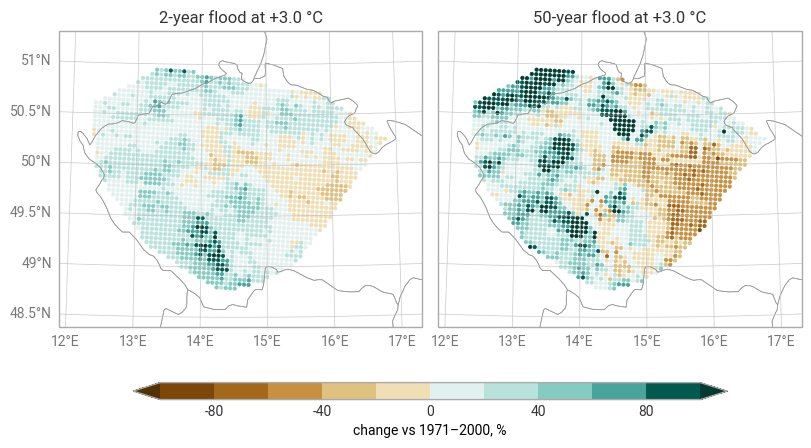

In [8]:
VAR_2Y, VAR_50Y = 'rdisreturnmax2_tmean', 'rdisreturnmax50_tmean'

figure = ekp.Figure(rows=1, columns=2, domain=[11.9, 17.3, 48.4, 51.3])

for ds, var, name in [(ds_poly2y, VAR_2Y, '2-year flood'), (ds_poly50y, VAR_50Y, '50-year flood')]:
    ax = figure.add_map()
    ax.point_cloud(ds[var].isel(datetimes=0, number=0, steps=0),
        x=ds['longitude'],
        y=ds['latitude'],
        s=6,
        style=ekp.Style(levels=change_levels, colors='BrBG', extend='both'))
    ax.title(f'{name} at +3.0 °C')

figure.coastlines()
figure.borders()
figure.gridlines()
figure.legend(label='change vs 1971–2000, %')
figure.show()

The maps show the same contrast: the 2-year panel is a gentle wash of pale teal, while the 50-year panel swings from strong increases in the north-west to strong decreases in the east. Rare floods do respond differently from routine ones, but a 50-year return level from a single 30-year window is also a far noisier estimate — separating the two needs the ensemble.

---

## Next steps

Now that you can retrieve the data, here are some things to try next:

- **Add the missing warming level** – run Example 1 again with `period: ['2_0_c']`
- **Sample the ensemble** – repeat a request with other `gcm`/`rcm` pairs, or with the catchment models `e_hypecatch_m00` … `e_hypecatch_m07`, and compare the spread between models with the climate signal
- **Ask for absolute values** – switch `variable_type` to `absolute_values` for the return level itself in m³/s
- **Swap the variable** – try `minimum_river_discharge` or `mean_soil_moisture` for the drought side, or the nutrient variables for water quality
- **Move to daily data** – set `product_type: 'essential_climate_variables'` with `time_aggregation: 'daily'` and a single-year `period` for discharge time series
- **Use a real boundary** – load a catchment shapefile and convert it to a polygon for the API

Please see the constraints file, which contains the valid values for the dataset.